# 새 구종 정의 → 투수 레퍼토리 군집화 (2단계 GMM 파이프라인)

`DBSCAN_EDA.ipynb` 에서 확인했듯 `ivb_ft` × `hb_ft` 평면은 **밀도 골짜기가 없는 연속체**라 DBSCAN으로는 나뉘지 않는다. 이 노트북은 목적 자체를 바꿔서 접근한다.

> **목표**: 패스트볼을 무브먼트·팔 각도 기준으로 더 세밀한 "새 구종"으로 나누고, **비슷한 새 구종을 주로 던지는 투수들끼리 묶는다.**

## 2단계 구조

```
[1단계]  투구 → GMM → 새 구종 K개에 대한 소속 확률 벡터  (하드 할당 아님)
                              ↓
[2단계]  투수-시즌별로 확률 벡터를 평균 → 레퍼토리 프로필 → 투수 군집화
```

### 왜 하드 할당이 아니라 확률인가

FF와 SI 경계에 걸친 공을 억지로 한쪽에 넣으면 그 오차가 투수 프로필에 누적된다. 경계 근처 공을 많이 던지는 투수일수록 프로필이 불안정해진다.

GMM은 각 투구에 `[0.6, 0.3, 0.1, ...]` 같은 **소속 확률**을 준다. 투수별로 이걸 평균 내면 합이 1인 K차원 레퍼토리 프로필이 되고, 경계에 걸친 공은 양쪽에 나눠 기여하므로 정보를 버리지 않는다. **겹침이 문제가 아니라 데이터가 된다.**

### 왜 "투수별 평균 무브먼트"가 아닌가

포심과 싱커를 반반 던지는 투수의 평균 무브먼트는 **둘 사이 빈 공간**에 찍히고, 그 위치는 커터만 던지는 투수와 거의 같다. 완전히 다른 유형인데 같은 점이 된다. 레퍼토리의 다봉성이 핵심 정보인데 평균이 그걸 뭉갠다. 확률 벡터 방식은 이 문제가 없다 — 앞의 투수는 `[FF .5, SI .5, FC 0]`, 뒤의 투수는 `[0, 0, 1]` 로 확실히 갈린다.

### 사용 변수

| 변수 | 단위 | 역할 |
|---|---|---|
| `ivb_ft` | inch | 체공시간 보정 수직 무브먼트 |
| `hb_ft` | inch | 체공시간 보정 수평 무브먼트 (암사이드 +) |
| `arm_angle` | degree | 릴리스 팔 각도 — 같은 무브먼트라도 팔 각도가 다르면 타자에겐 다른 공 |

단위가 섞여 있으므로(inch vs degree) **반드시 표준화**한다.

| 단계 | 내용 |
|---|---|
| 1 | 데이터 준비 — 학습연도 표본 추출 |
| 2 | 1단계 GMM — BIC로 K 선택 |
| 3 | 1단계 GMM — 최종 적합 및 새 구종 해석 |
| 4 | 2단계 — 투수-시즌 레퍼토리 프로필 생성 |
| 5 | 2단계 — 투수 군집화 |
| 6 | 결과 해석 — 군집별 대표 투수 |
| 7 | 연도 간 안정성 점검 |
| 8 | 한계와 다음 단계 |

In [1]:
from __future__ import annotations

import re
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

import sklearn
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 3.0.6 | numpy 2.5.3 | scikit-learn 1.9.1


## 0. 파라미터

In [2]:
# ---------------------------------------------------------------- 데이터 선택
YEARS: list[int] | None = None        # None = 읽을 수 있는 모든 연도
TRAIN_YEARS = [2021, 2022, 2023]      # GMM 을 적합할 연도 (기준 체공시간 학습연도와 동일)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# ------------------------------------------------------------- 1단계 (새 구종)
STAGE1_FEATURES = ["ivb_ft", "hb_ft", "arm_angle"]
K_RANGE = range(6, 11)                # 탐색할 성분 개수 (6~10)
K_SCAN_EXTRA = range(3, 13)           # BIC 곡선을 그릴 더 넓은 범위 (참고용)
K_OVERRIDE: int | None = None         # 숫자를 넣으면 BIC 자동선택 대신 그 값을 쓴다
GMM_FIT_SAMPLE = 200_000              # GMM 적합에 쓸 표본 크기 (전체를 다 쓰면 느리다)
GMM_BIC_SAMPLE = 60_000               # BIC 곡선 계산용 표본 (K 마다 적합하므로 더 작게)
COVARIANCE_TYPE = "full"              # 성분마다 자유로운 타원 모양 허용

# ------------------------------------------------------------ 2단계 (투수 군집)
MIN_PITCHES_PER_SEASON = 200          # 이보다 적게 던진 투수-시즌은 프로필이 노이즈라 제외
PITCHER_K_RANGE = range(2, 11)        # 투수 군집 개수 탐색 범위
PITCHER_K_OVERRIDE: int | None = None
USE_CLR = True                        # 레퍼토리는 합이 1인 조성 데이터 → CLR 변환 후 군집화

RANDOM_STATE = 42
CHUNKSIZE = 200_000

# 결과 저장 여부 (data/processed/pitcher_repertoire_clusters.csv)
SAVE_RESULTS = True

In [3]:
# ------------------------------------------------------------ 시각화 공통 설정
# 한글 폰트 — 없으면 축·범례의 한글이 모두 네모(두부)로 깨진다.
import matplotlib.font_manager as fm

KOREAN_FONTS = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic",
                "Noto Sans CJK KR", "Noto Sans KR", "Gulim", "Noto Sans CJK JP"]
_available = {f.name for f in fm.fontManager.ttflist}
_picked = next((f for f in KOREAN_FONTS if f in _available), None)
print(f"한글 폰트: {_picked}" if _picked else
      "⚠️  한글 폰트를 찾지 못했습니다. 그래프의 한글이 네모로 표시될 수 있습니다.")

# 색맹 안전성 검증을 통과한 3색 팔레트. 산점도는 모든 색 쌍이 구분돼야 해서
# 계열색은 3개까지만 쓰고, 그보다 많으면 small multiples(분할 패널)로 나눈다.
SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]
OTHER_COLOR, BACKDROP = "#6b6a66", "#dedcd4"
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"

sns.set_theme(style="white")
mpl.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlepad": 10, "figure.dpi": 110, "axes.unicode_minus": False,
})
if _picked:
    mpl.rcParams["font.family"] = _picked

AXIS_LABELS = {
    "ivb_ft": "ivb_ft — 보정 수직 무브먼트 (inch)",
    "hb_ft": "hb_ft — 보정 수평 무브먼트, 암사이드 + (inch)",
    "arm_angle": "arm_angle — 팔 각도 (°)",
}
PLOT_X, PLOT_Y = "hb_ft", "ivb_ft"   # 산점도 축 (Baseball Savant 관례와 동일한 배치)


# 표 출력 — pandas 의 .style 은 jinja2 를 요구한다. 없어도 죽지 않도록 감싼다.
def show_table(frame, formats=None, gradient=None, caption=None):
    try:
        styler = frame.style
    except (AttributeError, ImportError):
        if caption:
            print(caption)
        display(frame.round(4) if hasattr(frame, "round") else frame)
        return
    if formats is not None:
        styler = styler.format(formats)
    if gradient:
        keep = [c for c in gradient if c in frame.columns and frame[c].notna().any()]
        if keep:
            styler = styler.background_gradient(subset=keep, cmap="Blues")
    if caption:
        styler = styler.set_caption(caption)
    display(styler)

한글 폰트: Malgun Gothic


## 1. 데이터 준비

1단계 GMM은 **학습연도(`TRAIN_YEARS`)에서만 적합**한다. 2024·2025까지 넣어 적합하면 "새 구종"의 정의에 미래 정보가 섞이고, 연도 간 비교 척도도 달라진다. 체공시간 기준값을 2021~2023에서만 구한 것과 같은 논리다.

In [4]:
FILE_PATTERN = re.compile(r"^(?P<year>\d{4})_movement_reconciliation\.csv$")

# 읽을 컬럼 — 파일이 연도당 200~330MB 라 필요한 것만 지정하는 게 중요하다
READ_COLUMNS = ["game_year", "pitcher", "player_name", "pitch_type", "p_throws",
                "ivb_ft", "hb_ft", "arm_angle"]


def find_movement_files(processed_dir: Path, years: list[int] | None = None) -> dict[int, Path]:
    if not processed_dir.is_dir():
        raise FileNotFoundError(f"디렉토리를 찾을 수 없습니다: {processed_dir}")
    found = {int(m.group("year")): p
             for p in sorted(processed_dir.iterdir())
             if p.is_file() and (m := FILE_PATTERN.match(p.name))}
    if not found:
        raise FileNotFoundError(
            f"{processed_dir} 에 '{{연도}}_movement_reconciliation.csv' 가 없습니다. "
            "먼저 src/preprocessing/compute_movement_reconciliation.py 를 실행하세요.")
    if years is not None:
        wanted = {int(y) for y in years}
        missing = wanted - found.keys()
        if missing:
            raise FileNotFoundError(f"요청한 연도의 파일이 없습니다: {sorted(missing)}")
        found = {y: p for y, p in found.items() if y in wanted}
    return dict(sorted(found.items()))


def iter_chunks(path: Path, chunksize: int = CHUNKSIZE):
    """필요한 컬럼만 청크로 읽고, 1단계 변수에 결측이 있는 행은 버린다."""
    for chunk in pd.read_csv(path, usecols=READ_COLUMNS, chunksize=chunksize, low_memory=False):
        yield chunk.dropna(subset=STAGE1_FEATURES)


files = find_movement_files(PROCESSED_DIR, YEARS)
train_files = {y: p for y, p in files.items() if y in TRAIN_YEARS}
if not train_files:
    raise ValueError(f"학습연도 파일이 없습니다. TRAIN_YEARS={TRAIN_YEARS}, 가용={sorted(files)}")

print(f"전체 연도: {sorted(files)}")
print(f"학습연도  : {sorted(train_files)}  ← GMM 은 여기서만 적합")

전체 연도: [2021, 2022, 2023, 2024, 2025]
학습연도  : [2021, 2022, 2023]  ← GMM 은 여기서만 적합


In [5]:
# 학습연도에서 GMM 적합용 표본을 추출한다 (전체를 메모리에 올리지 않기 위해 청크 단위 비례추출)
rng = np.random.default_rng(RANDOM_STATE)
train_rows, total_train = [], 0

# player_name 같은 문자열 컬럼은 1단계에 필요 없다 — 메모리가 아깝다
TRAIN_KEEP = STAGE1_FEATURES + ["pitch_type", "p_throws", "game_year"]

for year, path in sorted(train_files.items()):
    year_rows = 0
    for chunk in iter_chunks(path):
        total_train += len(chunk)
        year_rows += len(chunk)
        train_rows.append(chunk[TRAIN_KEEP])
    print(f"  {path.name}: {year_rows:,}행")

train_data = pd.concat(train_rows, ignore_index=True)
del train_rows

if len(train_data) > GMM_FIT_SAMPLE:
    fit_data = train_data.sample(GMM_FIT_SAMPLE, random_state=RANDOM_STATE).reset_index(drop=True)
else:
    fit_data = train_data
print(f"\n학습연도 전체 {len(train_data):,}행 → GMM 적합 표본 {len(fit_data):,}행")

# 표준화 — inch 와 degree 를 같은 거리로 재면 안 되므로 필수
scaler = StandardScaler().fit(fit_data[STAGE1_FEATURES])
X_fit = scaler.transform(fit_data[STAGE1_FEATURES])

show_table(train_data[STAGE1_FEATURES].describe().T.round(2), caption="학습연도 1단계 변수 분포")

  2021_movement_reconciliation.csv: 404,246행
  2022_movement_reconciliation.csv: 337,978행
  2023_movement_reconciliation.csv: 401,525행

학습연도 전체 1,143,749행 → GMM 적합 표본 200,000행


,count,mean,std,min,25%,50%,75%,max
ivb_ft,1143749.000000,12.940000,5.400000,-14.240000,9.320000,14.070000,17.030000,33.090000
hb_ft,1143749.000000,8.140000,6.490000,-17.640000,4.030000,8.550000,13.080000,31.110000
arm_angle,1143749.000000,39.630000,12.870000,-70.700000,33.200000,40.800000,47.700000,84.500000


## 2. 1단계 GMM — `K` (새 구종 개수) 선택

**BIC**(베이즈 정보량 기준)가 낮을수록 좋다. 단 표본이 크면 BIC는 계속 더 복잡한 모델을 선호하므로, 무작정 최저값을 따르기보다 **곡선이 꺾이는 지점**과 **해석 가능성**을 같이 본다.

In [6]:
bic_rows = []
scan_ks = sorted(set(K_SCAN_EXTRA) | set(K_RANGE))
bic_sample = X_fit[rng.choice(len(X_fit), size=min(GMM_BIC_SAMPLE, len(X_fit)), replace=False)]
print(f"BIC 곡선 계산 (표본 {len(bic_sample):,}행, K={scan_ks[0]}~{scan_ks[-1]})")

for K in scan_ks:
    gmm = GaussianMixture(K, covariance_type=COVARIANCE_TYPE,
                          random_state=RANDOM_STATE, n_init=1, max_iter=300).fit(bic_sample)
    bic_rows.append({"K": K, "BIC": gmm.bic(bic_sample), "AIC": gmm.aic(bic_sample),
                     "수렴": bool(gmm.converged_)})

bic = pd.DataFrame(bic_rows).set_index("K")
bic["ΔBIC"] = bic["BIC"].diff()          # 음수 = 개선, 0 근처 = 더 늘려도 소용없음
bic["탐색범위"] = [k in K_RANGE for k in bic.index]
show_table(bic, {"BIC": "{:,.0f}", "AIC": "{:,.0f}", "ΔBIC": "{:,.0f}"}, caption="K별 정보량 기준")

BIC 곡선 계산 (표본 60,000행, K=3~12)


,BIC,AIC,수렴,ΔBIC,탐색범위
K,,,,,
3,"434,737","434,476",True,nan,False
4,"426,550","426,199",True,"-8,187",False
5,"425,539","425,097",True,"-1,011",False
6,"424,979","424,448",True,-559,True
7,"424,488","423,867",True,-491,True
8,"424,192","423,481",True,-296,True
9,"423,839","423,038",True,-353,True
10,"423,694","422,803",True,-145,True
11,"423,518","422,537",True,-177,False


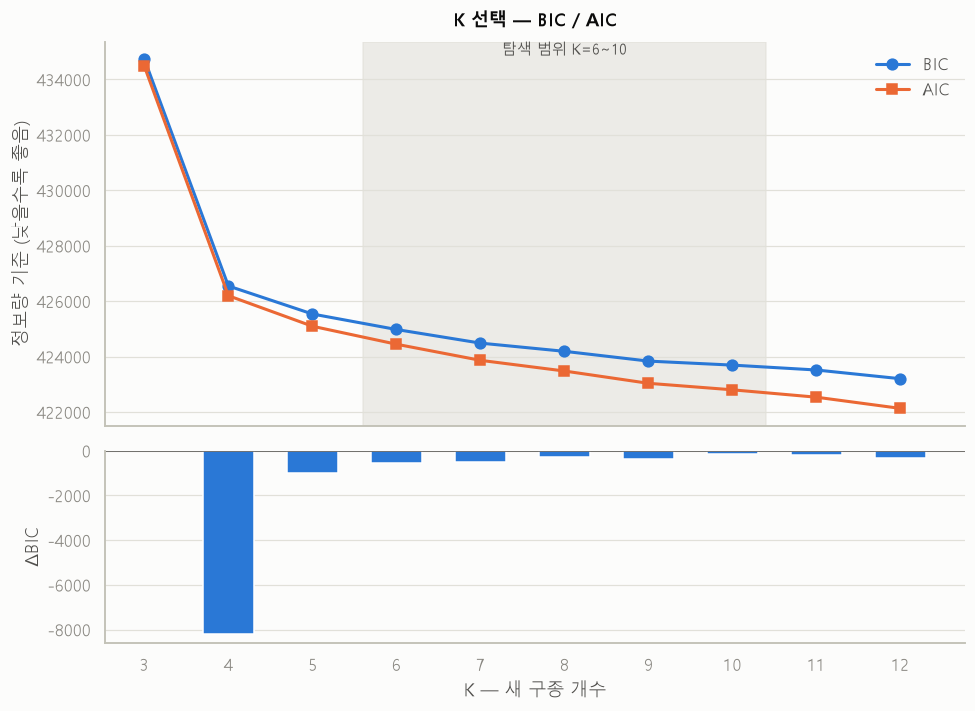

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6.6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(bic.index, bic["BIC"], marker="o", markersize=7, linewidth=2,
             color=SERIES_COLORS[0], label="BIC")
axes[0].plot(bic.index, bic["AIC"], marker="s", markersize=6, linewidth=2,
             color=SERIES_COLORS[1], label="AIC")
axes[0].axvspan(min(K_RANGE) - 0.4, max(K_RANGE) + 0.4, color=BACKDROP, alpha=0.5, zorder=0)
axes[0].annotate(f"탐색 범위 K={min(K_RANGE)}~{max(K_RANGE)}",
                 xy=(np.mean(list(K_RANGE)), axes[0].get_ylim()[1]),
                 ha="center", va="top", color=INK_2, fontsize=10)
axes[0].set_ylabel("정보량 기준 (낮을수록 좋음)")
axes[0].set_title("K 선택 — BIC / AIC")
axes[0].legend(frameon=False, labelcolor=INK_2)
axes[0].grid(axis="y")

# ΔBIC — 0 에 가까워지면 K 를 더 늘려도 얻는 게 없다는 뜻
delta = bic["ΔBIC"]
axes[1].bar(delta.index, delta.values, color=SERIES_COLORS[0], width=0.6)
axes[1].axhline(0, color=INK_2, linewidth=1)
axes[1].set_ylabel("ΔBIC")
axes[1].set_xlabel("K — 새 구종 개수")
axes[1].set_xticks(list(bic.index))
axes[1].grid(axis="y")

plt.tight_layout()
plt.show()

In [8]:
in_range = bic[bic["탐색범위"]]
auto_k = int(in_range["BIC"].idxmin())

# 참고: 곡선이 한 번 꺾이는(ΔBIC 가 양수로 올라서는) 직전 K — 해석 가능성 쪽 후보
rises = [k for k in in_range.index
         if pd.notna(bic.loc[k, "ΔBIC"]) and bic.loc[k, "ΔBIC"] > 0]
knee_k = min(rises) - 1 if rises else None

best_k = K_OVERRIDE if K_OVERRIDE is not None else auto_k
source = "사용자 지정(K_OVERRIDE)" if K_OVERRIDE is not None else "탐색범위 내 BIC 최저"

print(f"탐색범위 내 BIC 최저 : K={auto_k}")
if knee_k:
    print(f"BIC 곡선이 꺾이는 지점: K={knee_k}  (더 단순한 대안 — 해석이 쉬우면 K_OVERRIDE 로 지정)")
print(f"\n→ 선택한 K = {best_k}  ({source})")

탐색범위 내 BIC 최저 : K=10

→ 선택한 K = 10  (탐색범위 내 BIC 최저)


## 3. 1단계 GMM — 최종 적합과 새 구종 해석

선택한 `K` 로 학습연도 표본에 GMM을 적합한다. 이 모델이 **새 구종의 정의**이며, 이후 모든 연도에 이 하나의 모델을 그대로 적용한다.

In [9]:
gmm = GaussianMixture(best_k, covariance_type=COVARIANCE_TYPE, random_state=RANDOM_STATE,
                      n_init=3, max_iter=500).fit(X_fit)
print(f"GaussianMixture(K={best_k}, covariance_type='{COVARIANCE_TYPE}') "
      f"수렴={gmm.converged_} (반복 {gmm.n_iter_}회)")

# 성분 중심을 원래 단위로 되돌려 해석한다
centers = pd.DataFrame(scaler.inverse_transform(gmm.means_),
                       columns=STAGE1_FEATURES)
centers.index.name = "성분"
centers["비중"] = gmm.weights_

# 학습연도 전체에 대한 소속 확률 → 하드 할당은 해석용으로만 쓴다
X_train_all = scaler.transform(train_data[STAGE1_FEATURES])
proba_train = gmm.predict_proba(X_train_all)
hard = proba_train.argmax(axis=1)
train_data["성분"] = hard
# 소속 확률의 최대값 — 1 에 가까우면 그 공은 성분 경계에서 멀다
train_data["최대확률"] = proba_train.max(axis=1)

summary = centers.copy()
summary["투구수"] = pd.Series(hard).value_counts().reindex(range(best_k)).fillna(0).astype(int)
summary["평균확신도"] = train_data.groupby("성분")["최대확률"].mean().reindex(range(best_k))
dominant = (train_data.groupby("성분")["pitch_type"]
            .agg(lambda s: f"{s.mode().iloc[0]} {s.value_counts(normalize=True).iloc[0]:.0%}"))
summary["주요 구종"] = dominant
summary["좌투 비율"] = train_data.groupby("성분")["p_throws"].apply(lambda s: (s == "L").mean())

show_table(summary.round(2),
           {"비중": "{:.1%}", "투구수": "{:,}", "평균확신도": "{:.2f}", "좌투 비율": "{:.1%}"},
           caption=f"새 구종 {best_k}개 — 성분별 요약 (학습연도 기준)")

GaussianMixture(K=10, covariance_type='full') 수렴=True (반복 10회)


,ivb_ft,hb_ft,arm_angle,비중,투구수,평균확신도,주요 구종,좌투 비율
성분,,,,,,,,
0,14.850000,5.210000,40.670000,11.0%,"113,508",0.60,FF 89%,30.0%
1,9.650000,15.050000,39.990000,17.0%,"219,847",0.79,SI 93%,28.0%
2,16.310000,10.160000,38.190000,16.0%,"199,289",0.64,FF 92%,25.0%
3,18.260000,3.840000,55.020000,10.0%,"93,251",0.72,FF 92%,26.0%
4,-1.590000,12.550000,-19.590000,1.0%,"9,951",0.89,SI 66%,25.0%
5,17.650000,7.140000,48.080000,15.0%,"190,640",0.60,FF 96%,30.0%
6,8.180000,-0.220000,34.110000,6.0%,"43,984",0.71,FC 73%,31.0%
7,4.680000,16.030000,24.180000,7.0%,"60,660",0.77,SI 95%,32.0%
8,7.850000,-3.280000,44.310000,9.0%,"119,006",0.77,FC 88%,26.0%


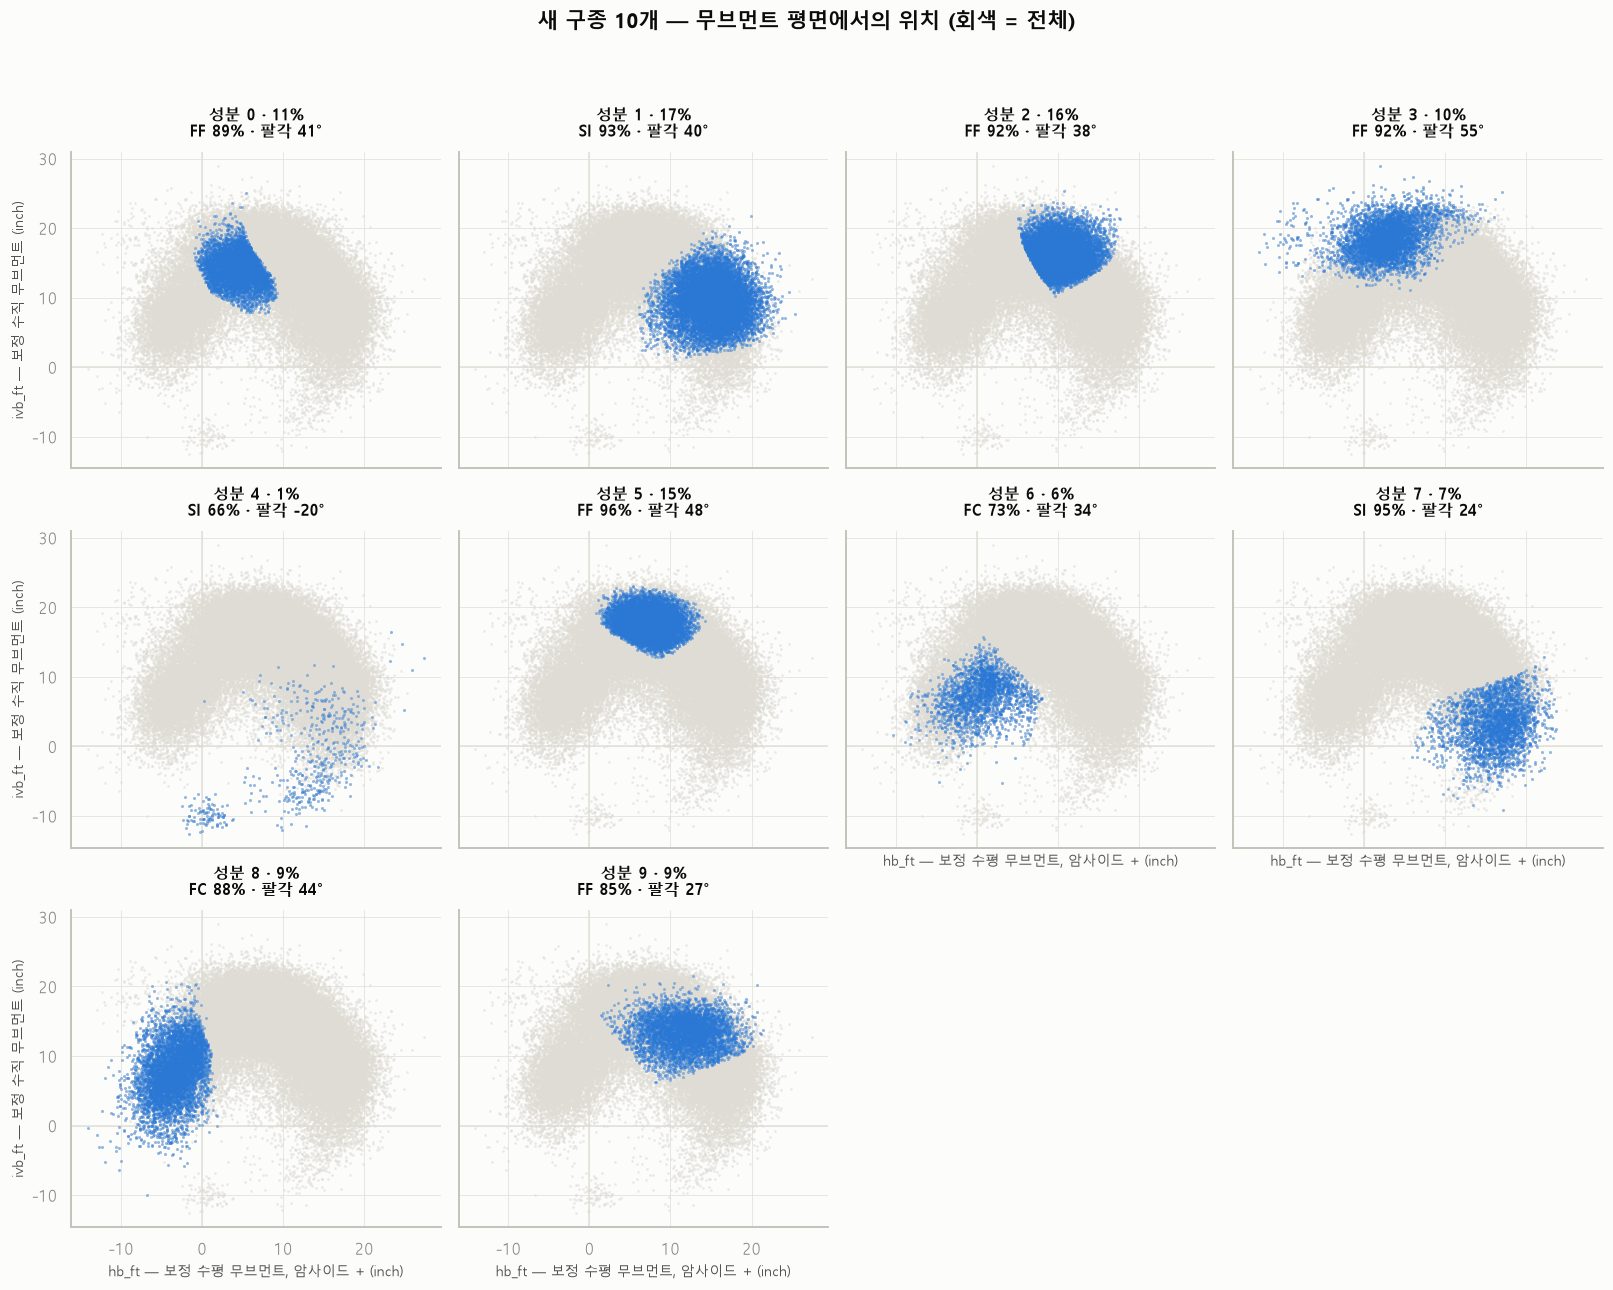

In [10]:
# 성분이 3개를 넘으므로 색으로 구분하지 않고 패널을 나눈다(small multiples).
# 각 패널: 회색 배경 = 전체 투구, 파란색 = 그 성분에 속한 투구.
plot_sample = train_data.sample(min(60_000, len(train_data)), random_state=RANDOM_STATE)
bx, by = plot_sample[PLOT_X].to_numpy(), plot_sample[PLOT_Y].to_numpy()
pad = 2.0
xlim = (bx.min() - pad, bx.max() + pad)
ylim = (by.min() - pad, by.max() + pad)

ncols = min(4, best_k)
nrows = int(np.ceil(best_k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.7 * ncols, 3.9 * nrows),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for comp in range(best_k):
    ax = axes[comp]
    ax.scatter(bx, by, s=3, c=BACKDROP, alpha=0.6, linewidths=0, rasterized=True, zorder=1)
    mask = (plot_sample["성분"] == comp).to_numpy()
    ax.scatter(bx[mask], by[mask], s=4, c=SERIES_COLORS[0], alpha=0.45,
               linewidths=0, rasterized=True, zorder=2)
    row = summary.loc[comp]
    ax.set_title(f"성분 {comp} · {row['비중']:.0%}\n"
                 f"{row['주요 구종']} · 팔각 {row['arm_angle']:.0f}°", fontsize=10.5)
    ax.set_xlim(*xlim); ax.set_ylim(*ylim)
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.axvline(0, color=GRID, linewidth=1, zorder=0)
    ax.grid(True, linewidth=0.5)

for ax in axes[best_k:]:
    ax.set_visible(False)
# 축을 공유하므로 라벨은 가장자리에만 — 패널마다 붙이면 글자가 그림을 덮는다
for i in range(best_k):
    last_in_column = i + ncols >= best_k
    if last_in_column:
        axes[i].set_xlabel(AXIS_LABELS[PLOT_X], fontsize=9)
    if i % ncols == 0:
        axes[i].set_ylabel(AXIS_LABELS[PLOT_Y], fontsize=9)

fig.suptitle(f"새 구종 {best_k}개 — 무브먼트 평면에서의 위치 (회색 = 전체)",
             fontsize=14, fontweight="bold", color=INK, y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

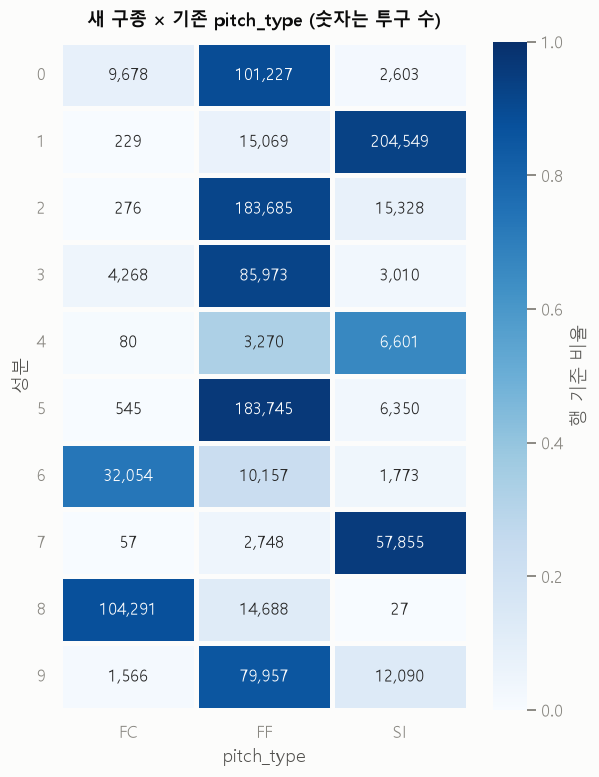

기존 구종이 갈라진 정도 (해당 구종이 10% 이상을 차지하는 성분 수):
  FC: 2개 성분 [6, 8]
  FF: 8개 성분 [0, 2, 3, 4, 5, 6, 8, 9]
  SI: 4개 성분 [1, 4, 7, 9]

숫자가 1이면 기존 라벨을 그대로 재현한 것이고, 2 이상이면 더 세밀하게 나눈 것이다.


In [11]:
# 새 구종이 기존 pitch_type 을 그냥 재현하는가, 아니면 더 잘게 쪼개는가?
ct_counts = pd.crosstab(train_data["성분"], train_data["pitch_type"])
ct_share = pd.crosstab(train_data["성분"], train_data["pitch_type"], normalize="index")

fig, ax = plt.subplots(figsize=(5.6, 0.5 * best_k + 2.2))
sns.heatmap(ct_share, annot=ct_counts, fmt=",d", cmap="Blues", vmin=0, vmax=1,
            linewidths=2, linecolor="#fcfcfb", cbar_kws={"label": "행 기준 비율"}, ax=ax)
ax.set_title("새 구종 × 기존 pitch_type (숫자는 투구 수)")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# 기존 구종이 몇 개의 새 성분으로 쪼개졌는지
split = (ct_share.T > 0.10).sum(axis=1)
print("기존 구종이 갈라진 정도 (해당 구종이 10% 이상을 차지하는 성분 수):")
for pitch_type, n in split.items():
    members = [int(c) for c in ct_share.index if ct_share.loc[c, pitch_type] > 0.10]
    print(f"  {pitch_type}: {n}개 성분 {members}")
print("\n숫자가 1이면 기존 라벨을 그대로 재현한 것이고, 2 이상이면 더 세밀하게 나눈 것이다.")

## 4. 2단계 — 투수-시즌 레퍼토리 프로필 만들기

**모든 연도**의 모든 투구에 1단계 GMM을 적용해 소속 확률을 구하고, 투수-시즌별로 평균 낸다. 결과는 각 투수-시즌마다 합이 1인 `K`차원 벡터다.

전체 파일을 메모리에 올리지 않도록 청크 단위로 읽으면서 **합계만 누적**한다. 연도당 200~330MB 파일 5개를 읽으므로 몇 분 걸릴 수 있다.

> 단위가 투수가 아니라 **투수-시즌**인 이유: 투수는 해마다 구종을 바꾼다. "A투수 2023"과 "A투수 2025"를 별개 점으로 두면 그 이동 자체가 결과가 된다.

In [12]:
# (pitcher, game_year) → 확률 합계 / 투구 수 / 기존 구종 카운트 를 누적한다
proba_sum: dict[tuple[int, int], np.ndarray] = defaultdict(lambda: np.zeros(best_k))
pitch_count: dict[tuple[int, int], int] = defaultdict(int)
legacy_count: dict[tuple[int, int], dict[str, int]] = defaultdict(lambda: defaultdict(int))
name_of: dict[int, str] = {}
hand_of: dict[int, str] = {}

for year, path in sorted(files.items()):
    rows = 0
    for chunk in iter_chunks(path):
        rows += len(chunk)
        p = gmm.predict_proba(scaler.transform(chunk[STAGE1_FEATURES]))

        # 행 단위 파이썬 루프는 190만 행에서 너무 느리다 → groupby 로 한 번에 합친다
        index = pd.MultiIndex.from_arrays(
            [chunk["pitcher"].to_numpy(), chunk["game_year"].to_numpy()],
            names=["pitcher", "year"])
        grouped = pd.DataFrame(p, index=index).groupby(level=[0, 1])
        for key, row in zip(grouped.sum().index, grouped.sum().to_numpy()):
            proba_sum[key] += row
        for key, n in grouped.size().items():
            pitch_count[key] += int(n)

        legacy = chunk.groupby(["pitcher", "game_year", "pitch_type"]).size()
        for (pitcher, yr, pt), n in legacy.items():
            legacy_count[(pitcher, yr)][pt] += int(n)

        unique = chunk.drop_duplicates("pitcher")
        name_of.update(dict(zip(unique["pitcher"], unique["player_name"])))
        hand_of.update(dict(zip(unique["pitcher"], unique["p_throws"])))
    print(f"  {path.name}: {rows:,}행 처리")

print(f"\n투수-시즌 {len(proba_sum):,}개 집계 완료")

  2021_movement_reconciliation.csv: 404,246행 처리
  2022_movement_reconciliation.csv: 337,978행 처리
  2023_movement_reconciliation.csv: 401,525행 처리
  2024_movement_reconciliation.csv: 401,694행 처리
  2025_movement_reconciliation.csv: 265,440행 처리

투수-시즌 4,042개 집계 완료


In [13]:
component_cols = [f"C{i}" for i in range(best_k)]

records = []
for (pitcher, year), total in proba_sum.items():
    n = pitch_count[(pitcher, year)]
    legacy = legacy_count[(pitcher, year)]
    records.append({
        "pitcher": int(pitcher), "player_name": name_of.get(pitcher, "?"),
        "p_throws": hand_of.get(pitcher, "?"), "game_year": int(year), "투구수": n,
        **dict(zip(component_cols, total / n)),
        **{f"legacy_{pt}": legacy.get(pt, 0) / n for pt in ["FF", "SI", "FC"]},
    })

repertoire_all = pd.DataFrame(records).sort_values(["player_name", "game_year"])
repertoire = repertoire_all[repertoire_all["투구수"] >= MIN_PITCHES_PER_SEASON].reset_index(drop=True)

print(f"전체 투수-시즌 {len(repertoire_all):,}개")
print(f"  → {MIN_PITCHES_PER_SEASON}구 이상: {len(repertoire):,}개 "
      f"({len(repertoire) / len(repertoire_all):.0%}), 투수 {repertoire.pitcher.nunique():,}명")
print(f"  연도별: {repertoire.game_year.value_counts().sort_index().to_dict()}")

show_table(repertoire.head(8)[["player_name", "game_year", "투구수"] + component_cols].round(3),
           caption="레퍼토리 프로필 예시 (각 행의 C0~C%d 합 = 1)" % (best_k - 1))

전체 투수-시즌 4,042개
  → 200구 이상: 2,566개 (63%), 투수 1,053명
  연도별: {2021: 547, 2022: 512, 2023: 538, 2024: 521, 2025: 448}


,player_name,game_year,투구수,C0,C1,C2,C3,C4,C5,C6,C7,C8,C9
0,"Abbott, Andrew",2023,949,0.182000,0.021000,0.213000,0.077000,0.000000,0.497000,0.002000,0.000000,0.000000,0.007000
1,"Abbott, Andrew",2024,1249,0.140000,0.034000,0.331000,0.050000,0.000000,0.429000,0.002000,0.000000,0.000000,0.013000
2,"Abbott, Andrew",2025,903,0.118000,0.065000,0.172000,0.076000,0.000000,0.475000,0.030000,0.001000,0.058000,0.006000
3,"Abbott, Cory",2021,207,0.104000,0.025000,0.489000,0.042000,0.000000,0.285000,0.001000,0.001000,0.000000,0.054000
4,"Abbott, Cory",2022,402,0.079000,0.008000,0.617000,0.002000,0.000000,0.020000,0.001000,0.001000,0.000000,0.272000
5,"Abbott, Cory",2023,323,0.137000,0.005000,0.628000,0.006000,0.000000,0.061000,0.001000,0.000000,0.000000,0.161000
6,"Abreu, Albert",2021,313,0.008000,0.307000,0.394000,0.003000,0.000000,0.010000,0.000000,0.029000,0.000000,0.249000
7,"Abreu, Albert",2022,297,0.014000,0.338000,0.409000,0.004000,0.000000,0.021000,0.000000,0.029000,0.000000,0.186000


## 5. 2단계 — 투수 군집화

레퍼토리 프로필은 합이 1인 **조성 데이터(compositional data)** 라 유클리드 거리가 엄밀히는 맞지 않는다. `USE_CLR = True` 면 CLR(중심 로그비) 변환을 거쳐 군집화한다.

$$\text{clr}(x)_i = \ln \frac{x_i}{\sqrt[K]{\prod_j x_j}}$$

여기서는 **KMeans** 와 **DBSCAN** 을 둘 다 돌려 비교한다. 투구 평면과 달리 투수 레퍼토리는 실제로 덩어리가 질 가능성이 있어, 1,000~1,500개 점 규모에서는 DBSCAN이 잘 맞을 수도 있다.

In [14]:
def clr_transform(proportions: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """조성 데이터를 CLR 변환한다. 0 이 있으면 로그가 발산하므로 eps 를 더하고 재정규화."""
    p = proportions + eps
    p = p / p.sum(axis=1, keepdims=True)
    log_p = np.log(p)
    return log_p - log_p.mean(axis=1, keepdims=True)


P = repertoire[component_cols].to_numpy()
Z = clr_transform(P) if USE_CLR else P
Z = StandardScaler().fit_transform(Z)
print(f"군집 입력: {Z.shape[0]:,} 투수-시즌 × {Z.shape[1]}차원 "
      f"({'CLR 변환' if USE_CLR else '원 비율'} 후 표준화)")

km_rows = []
for k in PITCHER_K_RANGE:
    km = KMeans(k, random_state=RANDOM_STATE, n_init=10).fit(Z)
    km_rows.append({"k": k, "실루엣": silhouette_score(Z, km.labels_),
                    "데이비스-볼딘": davies_bouldin_score(Z, km.labels_),
                    "관성": km.inertia_})
km_scan = pd.DataFrame(km_rows).set_index("k")
show_table(km_scan, {"실루엣": "{:.4f}", "데이비스-볼딘": "{:.4f}", "관성": "{:,.0f}"},
           gradient=["실루엣"], caption="KMeans — 투수 군집 개수 탐색")

군집 입력: 2,566 투수-시즌 × 10차원 (CLR 변환 후 표준화)


,실루엣,데이비스-볼딘,관성
k,,,
2,0.3464,1.2347,"17,027"
3,0.2620,1.2379,"13,463"
4,0.2549,1.2420,"11,372"
5,0.2569,1.2021,"9,953"
6,0.2594,1.1835,"8,828"
7,0.2549,1.1528,"7,977"
8,0.2507,1.1430,"7,375"
9,0.2334,1.1856,"6,880"
10,0.2272,1.1967,"6,496"


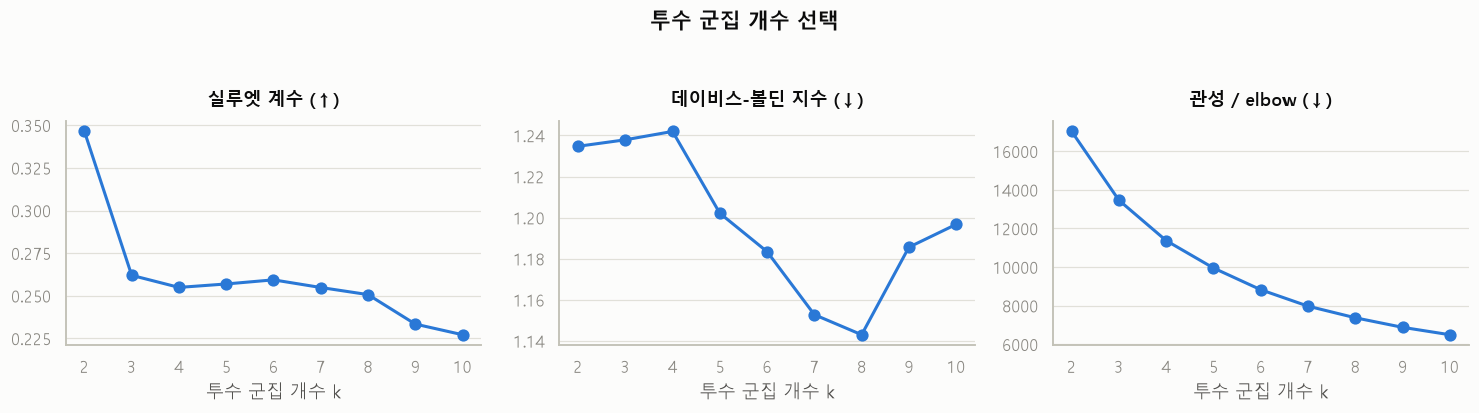

선택한 투수 군집 개수 k = 2 (실루엣 최대)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, (col, title) in zip(axes, [("실루엣", "실루엣 계수 (↑)"),
                                   ("데이비스-볼딘", "데이비스-볼딘 지수 (↓)"),
                                   ("관성", "관성 / elbow (↓)")]):
    ax.plot(km_scan.index, km_scan[col], marker="o", markersize=7,
            linewidth=2, color=SERIES_COLORS[0])
    ax.set_title(title)
    ax.set_xlabel("투수 군집 개수 k")
    ax.set_xticks(list(km_scan.index))
    ax.grid(axis="y")
fig.suptitle("투수 군집 개수 선택", fontsize=14, fontweight="bold", color=INK)
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

best_pk = PITCHER_K_OVERRIDE or int(km_scan["실루엣"].idxmax())
print(f"선택한 투수 군집 개수 k = {best_pk} "
      f"({'사용자 지정' if PITCHER_K_OVERRIDE else '실루엣 최대'})")

In [17]:
# 하이퍼파라미터 임의 설정
best_pk = 8

In [18]:
kmeans = KMeans(best_pk, random_state=RANDOM_STATE, n_init=20).fit(Z)
repertoire["군집"] = kmeans.labels_

# DBSCAN 비교 — k-distance 로 eps 를 잡고 돌려본다
from sklearn.neighbors import NearestNeighbors

min_samples = max(5, Z.shape[1] + 1)
nn = NearestNeighbors(n_neighbors=min_samples).fit(Z)
kd = np.sort(nn.kneighbors(Z)[0][:, -1])
eps_guess = float(np.quantile(kd, 0.90))
db_labels = DBSCAN(eps=eps_guess, min_samples=min_samples).fit_predict(Z)
db_n = len(set(db_labels)) - (1 if -1 in db_labels else 0)

print(f"[KMeans ] k={best_pk} | 실루엣 {silhouette_score(Z, kmeans.labels_):.4f} | "
      f"데이비스-볼딘 {davies_bouldin_score(Z, kmeans.labels_):.4f}")
if db_n >= 2:
    core = db_labels != -1
    print(f"[DBSCAN ] eps={eps_guess:.3f} min_samples={min_samples} | 군집 {db_n}개 | "
          f"노이즈 {(~core).mean():.1%} | 실루엣 {silhouette_score(Z[core], db_labels[core]):.4f}")
else:
    print(f"[DBSCAN ] eps={eps_guess:.3f} min_samples={min_samples} | "
          f"군집 {db_n}개 — 레퍼토리 공간에도 뚜렷한 밀도 경계는 없음 (KMeans 결과를 사용)")

show_table(repertoire["군집"].value_counts().sort_index().rename("투수-시즌 수").to_frame(),
           {"투수-시즌 수": "{:,}"}, caption="투수 군집 크기")

[KMeans ] k=8 | 실루엣 0.2507 | 데이비스-볼딘 1.1430
[DBSCAN ] eps=1.379 min_samples=11 | 군집 1개 — 레퍼토리 공간에도 뚜렷한 밀도 경계는 없음 (KMeans 결과를 사용)


,투수-시즌 수
군집,
0,133
1,341
2,372
3,613
4,490
5,233
6,294
7,90


## 6. 결과 해석 — 군집별 레퍼토리와 대표 투수

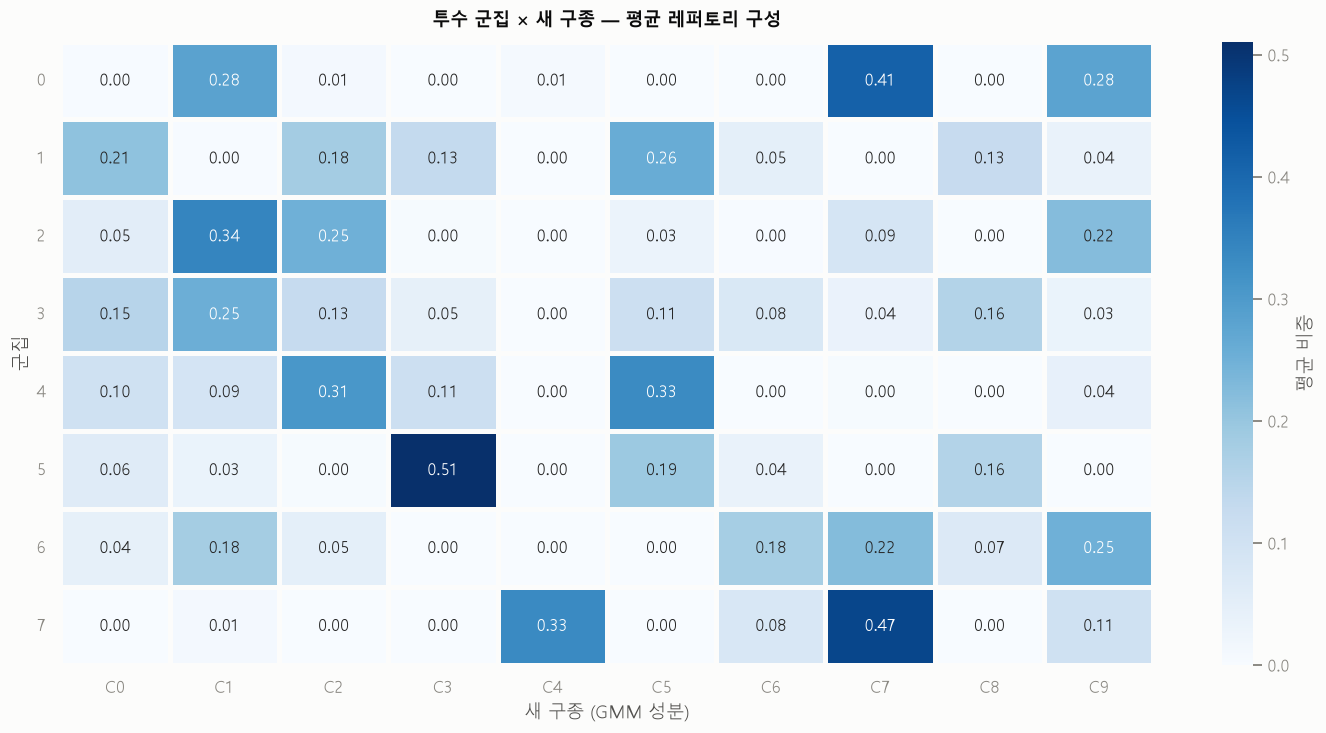

,투수-시즌,좌투 비율,주력 구종
군집,,,
0,133,40%,"C7(41%, SI 95%, ivb 5/hb 16/팔각 24°) + C1(28%, SI 93%, ivb 10/hb 15/팔각 40°)"
1,341,28%,"C5(26%, FF 96%, ivb 18/hb 7/팔각 48°) + C0(21%, FF 89%, ivb 15/hb 5/팔각 41°)"
2,372,26%,"C1(34%, SI 93%, ivb 10/hb 15/팔각 40°) + C2(25%, FF 92%, ivb 16/hb 10/팔각 38°)"
3,613,26%,"C1(25%, SI 93%, ivb 10/hb 15/팔각 40°) + C8(16%, FC 88%, ivb 8/hb -3/팔각 44°)"
4,490,27%,"C5(33%, FF 96%, ivb 18/hb 7/팔각 48°) + C2(31%, FF 92%, ivb 16/hb 10/팔각 38°)"
5,233,35%,"C3(51%, FF 92%, ivb 18/hb 4/팔각 55°) + C5(19%, FF 96%, ivb 18/hb 7/팔각 48°)"
6,294,22%,"C9(25%, FF 85%, ivb 14/hb 12/팔각 27°) + C7(22%, SI 95%, ivb 5/hb 16/팔각 24°)"
7,90,33%,"C7(47%, SI 95%, ivb 5/hb 16/팔각 24°) + C4(33%, SI 66%, ivb -2/hb 13/팔각 -20°)"


In [19]:
# 군집별 평균 레퍼토리 — 어떤 새 구종을 주로 던지는 집단인가
profile = repertoire.groupby("군집")[component_cols].mean()

fig, ax = plt.subplots(figsize=(1.0 * best_k + 3.2, 0.55 * best_pk + 2.4))
sns.heatmap(profile, annot=True, fmt=".2f", cmap="Blues", vmin=0,
            vmax=float(profile.to_numpy().max()), linewidths=2, linecolor="#fcfcfb",
            cbar_kws={"label": "평균 비중"}, ax=ax)
ax.set_title("투수 군집 × 새 구종 — 평균 레퍼토리 구성")
ax.set_xlabel("새 구종 (GMM 성분)")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

# 각 군집을 한 줄로 설명 — 비중이 큰 성분 두 개와 그 성분의 특성
desc = []
for c in profile.index:
    top = profile.loc[c].sort_values(ascending=False).head(2)
    parts = []
    for comp_name, share in top.items():
        comp = int(comp_name[1:])
        row = summary.loc[comp]
        parts.append(f"{comp_name}({share:.0%}, {row['주요 구종']}, "
                     f"ivb {row['ivb_ft']:.0f}/hb {row['hb_ft']:.0f}/팔각 {row['arm_angle']:.0f}°)")
    desc.append({"군집": c, "투수-시즌": int((repertoire['군집'] == c).sum()),
                 "좌투 비율": (repertoire.loc[repertoire["군집"] == c, "p_throws"] == "L").mean(),
                 "주력 구종": " + ".join(parts)})
show_table(pd.DataFrame(desc).set_index("군집"),
           {"투수-시즌": "{:,}", "좌투 비율": "{:.0%}"}, caption="군집 요약")

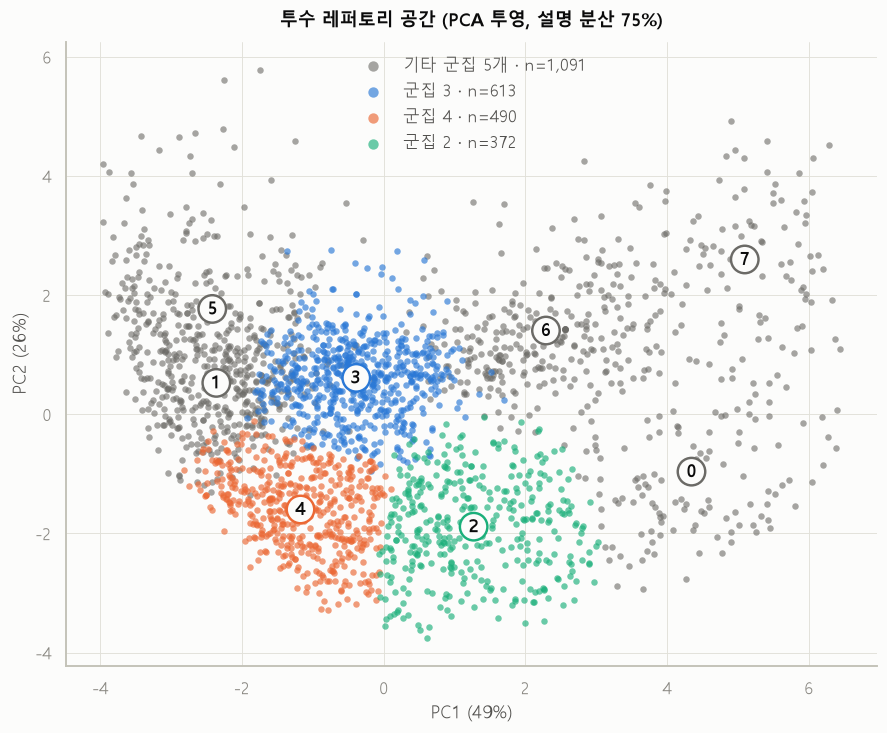

In [20]:
# 레퍼토리 공간을 PCA 2차원으로 투영해 군집을 본다.
# 산점도는 모든 색 쌍이 구분돼야 해서 크기 상위 3개 군집만 계열색, 나머지는 '기타'.
pca = PCA(n_components=2, random_state=RANDOM_STATE).fit(Z)
XY = pca.transform(Z)
order = repertoire["군집"].value_counts().index.tolist()
top3, rest = order[:3], order[3:]

fig, ax = plt.subplots(figsize=(8.2, 6.8))
if rest:
    m = repertoire["군집"].isin(rest).to_numpy()
    ax.scatter(XY[m, 0], XY[m, 1], s=18, c=OTHER_COLOR, alpha=0.6, linewidths=0,
               label=f"기타 군집 {len(rest)}개 · n={m.sum():,}")
for rank, c in enumerate(top3):
    m = (repertoire["군집"] == c).to_numpy()
    ax.scatter(XY[m, 0], XY[m, 1], s=18, c=SERIES_COLORS[rank], alpha=0.65,
               linewidths=0, label=f"군집 {c} · n={m.sum():,}")
# 모든 군집 중심에 직접 라벨 (색만으로 식별하지 않도록)
for c in order:
    m = (repertoire["군집"] == c).to_numpy()
    color = SERIES_COLORS[top3.index(c)] if c in top3 else OTHER_COLOR
    ax.annotate(str(c), (XY[m, 0].mean(), XY[m, 1].mean()), color=INK, fontweight="bold",
                fontsize=12, ha="center", va="center", zorder=5,
                bbox=dict(boxstyle="circle,pad=0.25", fc="#fcfcfb", ec=color, lw=1.6))

var = pca.explained_variance_ratio_
ax.set_title(f"투수 레퍼토리 공간 (PCA 투영, 설명 분산 {var.sum():.0%})")
ax.set_xlabel(f"PC1 ({var[0]:.0%})")
ax.set_ylabel(f"PC2 ({var[1]:.0%})")
ax.grid(True, linewidth=0.6)
ax.legend(frameon=False, labelcolor=INK_2, markerscale=1.6, loc="best")
plt.tight_layout()
plt.show()

In [21]:
# 군집별 대표 투수 — 군집 중심에 가장 가까운 투수-시즌
centers_z = kmeans.cluster_centers_
distance = np.linalg.norm(Z - centers_z[kmeans.labels_], axis=1)
repertoire["중심거리"] = distance

for c in sorted(repertoire["군집"].unique()):
    sub = repertoire[repertoire["군집"] == c].nsmallest(6, "중심거리")
    print(f"\n━━━ 군집 {c} — {(repertoire['군집'] == c).sum():,} 투수-시즌 " + "━" * 22)
    for _, r in sub.iterrows():
        legacy = " / ".join(f"{pt} {r[f'legacy_{pt}']:.0%}" for pt in ["FF", "SI", "FC"])
        top = r[component_cols].astype(float).sort_values(ascending=False).head(2)
        mix = " + ".join(f"{k} {v:.0%}" for k, v in top.items())
        print(f"   {r.player_name:<24} {int(r.game_year)}  {int(r['투구수']):>5}구  "
              f"[{mix}]   기존: {legacy}")


━━━ 군집 0 — 133 투수-시즌 ━━━━━━━━━━━━━━━━━━━━━━
   Chargois, JT             2023    415구  [C1 46% + C7 38%]   기존: FF 9% / SI 91% / FC 0%
   Castillo, Diego          2021    294구  [C7 56% + C1 35%]   기존: FF 11% / SI 89% / FC 0%
   Chargois, JT             2021    368구  [C1 48% + C7 32%]   기존: FF 10% / SI 90% / FC 0%
   Crichton, Stefan         2021    257구  [C7 45% + C1 39%]   기존: FF 1% / SI 99% / FC 0%
   Wood, Alex               2023    762구  [C9 53% + C7 38%]   기존: FF 0% / SI 100% / FC 0%
   Wood, Alex               2024    346구  [C9 56% + C7 35%]   기존: FF 0% / SI 100% / FC 0%

━━━ 군집 1 — 341 투수-시즌 ━━━━━━━━━━━━━━━━━━━━━━
   Gore, MacKenzie          2025   1040구  [C5 39% + C2 25%]   기존: FF 91% / SI 0% / FC 9%
   Boyle, Joe               2024    568구  [C5 35% + C3 30%]   기존: FF 100% / SI 0% / FC 0%
   Wilson, Steven           2024    255구  [C5 55% + C3 15%]   기존: FF 97% / SI 0% / FC 3%
   Garza, Justin            2023    250구  [C2 24% + C8 24%]   기존: FF 71% / SI 0% / FC 29%
   Gallen, Zac

## 7. 연도 간 안정성 점검

1단계 GMM은 2021~2023에서만 적합했다. 새 구종 체계가 쓸 만하려면 **2024·2025에도 비슷한 비율로 나타나야** 한다. 비중이 크게 흔들리면 그 성분은 학습연도에만 있던 우연한 구조라는 뜻이다.

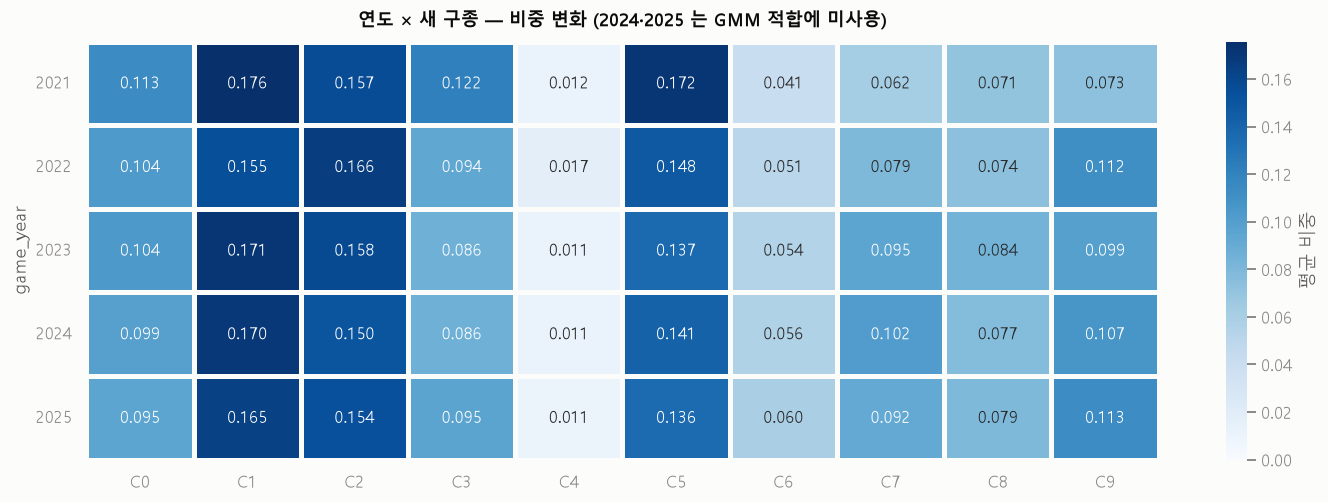

,학습연도 평균,검증연도 평균,변화,상대변화
C0,0.107,0.097,-0.010,-9.3%
C1,0.167,0.167,-0.000,-0.0%
C2,0.161,0.152,-0.008,-5.2%
C3,0.101,0.091,-0.010,-9.9%
C4,0.013,0.011,-0.002,-17.9%
C5,0.152,0.139,-0.013,-8.8%
C6,0.049,0.058,+0.009,+18.2%
C7,0.079,0.097,+0.018,+23.0%
C8,0.076,0.078,+0.002,+2.3%
C9,0.095,0.110,+0.015,+16.1%



최대 상대변화 23.0% → 일부 성분의 비중이 크게 변했습니다. 그 성분은 해석에 주의하세요.


In [22]:
year_share = (repertoire.groupby("game_year")[component_cols].mean())

fig, ax = plt.subplots(figsize=(1.0 * best_k + 3.2, 0.5 * len(year_share) + 2.2))
sns.heatmap(year_share, annot=True, fmt=".3f", cmap="Blues", vmin=0,
            vmax=float(year_share.to_numpy().max()), linewidths=2, linecolor="#fcfcfb",
            cbar_kws={"label": "평균 비중"}, ax=ax)
ax.set_title("연도 × 새 구종 — 비중 변화 (2024·2025 는 GMM 적합에 미사용)")
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

train_mean = year_share.loc[year_share.index.isin(TRAIN_YEARS)].mean()
test_years = [y for y in year_share.index if y not in TRAIN_YEARS]
if test_years:
    test_mean = year_share.loc[test_years].mean()
    drift = pd.DataFrame({"학습연도 평균": train_mean, "검증연도 평균": test_mean})
    drift["변화"] = drift["검증연도 평균"] - drift["학습연도 평균"]
    drift["상대변화"] = drift["변화"] / drift["학습연도 평균"]
    show_table(drift, {"학습연도 평균": "{:.3f}", "검증연도 평균": "{:.3f}",
                       "변화": "{:+.3f}", "상대변화": "{:+.1%}"},
               caption=f"학습({TRAIN_YEARS}) vs 검증({test_years})")
    worst = drift["상대변화"].abs().max()
    print(f"\n최대 상대변화 {worst:.1%} → " +
          ("안정적입니다 (20% 미만)." if worst < 0.20 else
           "일부 성분의 비중이 크게 변했습니다. 그 성분은 해석에 주의하세요."))

In [23]:
# 같은 투수가 해마다 군집을 옮기는가? — 군집 정의가 안정적인지에 대한 또 하나의 점검
moves = (repertoire.sort_values(["pitcher", "game_year"])
         .groupby("pitcher")["군집"].agg(["nunique", "count"]))
multi = moves[moves["count"] >= 2]
if len(multi):
    print(f"2시즌 이상 등장한 투수 {len(multi):,}명")
    print(f"  같은 군집 유지: {(multi['nunique'] == 1).sum():,}명 "
          f"({(multi['nunique'] == 1).mean():.0%})")
    print(f"  군집 이동     : {(multi['nunique'] > 1).sum():,}명 "
          f"({(multi['nunique'] > 1).mean():.0%})")
    print("\n유지 비율이 높을수록 군집이 '투수의 성질'을 잡아낸 것이고,")
    print("낮으면 군집 경계가 불안정하거나 실제로 구종을 자주 바꾸는 것이다.")

2시즌 이상 등장한 투수 680명
  같은 군집 유지: 373명 (55%)
  군집 이동     : 307명 (45%)

유지 비율이 높을수록 군집이 '투수의 성질'을 잡아낸 것이고,
낮으면 군집 경계가 불안정하거나 실제로 구종을 자주 바꾸는 것이다.


In [24]:
if SAVE_RESULTS:
    out_path = PROCESSED_DIR / "pitcher_repertoire_clusters.csv"
    save_cols = (["pitcher", "player_name", "p_throws", "game_year", "투구수", "군집"]
                 + component_cols + [f"legacy_{pt}" for pt in ["FF", "SI", "FC"]])
    repertoire[save_cols].to_csv(out_path, index=False, encoding="utf-8-sig")
    print(f"저장: {out_path}  ({len(repertoire):,}행)")

    comp_path = PROCESSED_DIR / "new_pitch_type_components.csv"
    summary.to_csv(comp_path, encoding="utf-8-sig")
    print(f"저장: {comp_path}  (새 구종 {best_k}개 정의)")
else:
    print("SAVE_RESULTS = False — 저장하지 않았습니다.")

저장: c:\YSAL_Github\9th-first-project-baseball-1\data\processed\pitcher_repertoire_clusters.csv  (2,566행)
저장: c:\YSAL_Github\9th-first-project-baseball-1\data\processed\new_pitch_type_components.csv  (새 구종 10개 정의)


## 8. 한계와 다음 단계

### 이 접근이 실제로 한 것

1. **새 구종 정의** — 무브먼트 2차원 + 팔 각도로 GMM을 돌려, 기존 FF/SI/FC보다 세밀한 성분을 얻었다. 3번 절의 교차표에서 기존 구종 하나가 몇 개 성분으로 갈라졌는지 확인할 수 있다. 갈라지지 않았다면(전부 1개) 기존 라벨을 재현한 것뿐이라 이 단계의 가치가 없다.
2. **투수 군집화** — 투구 평면과 달리 여기서는 각 점이 투수-시즌이고, 좌표가 "어떤 구종을 얼마나 던지는가"라 애초에 군집이 생길 여지가 있다.

### 알아둘 한계

- **`pitch_type` 은 정답이 아니다.** Statcast의 분류 모델 출력이다. 새 구종이 기존 라벨과 어긋나는 게 꼭 오류는 아니며, 오히려 그 지점이 흥미로울 수 있다.
- **FF/SI/FC는 모두 패스트볼**이라 여기서 나오는 "새 구종"은 새로운 종이 아니라 **연속체를 자른 구간**이다. 성분 경계 근처 투구의 `최대확률` 이 낮게 나오는 것이 그 증거다.
- **GMM은 타원을 가정한다.** 무브먼트 분포가 초승달 모양이라 성분 하나가 곡선 구간을 타원으로 근사하면서 실제보다 넓게 잡을 수 있다.
- **구속을 넣지 않았다.** 100마일 커터와 88마일 커터가 같은 성분에 들어간다. 구종을 나누는 관점에서는 `release_speed` 를 넣는 게 자연스러우므로, `STAGE1_FEATURES` 에 추가해 결과가 어떻게 달라지는지 비교해볼 만하다.
- **변화구가 빠져 있다.** 전처리에서 FF/SI/FC만 남겼기 때문에, 여기서 말하는 "레퍼토리"는 **패스트볼 레퍼토리**다. 진짜 투수 유형 분류라면 슬라이더·커브·체인지업이 들어가야 한다. 이게 아마 가장 큰 제약이다.

### 다음에 해볼 만한 것

1. **`STAGE1_FEATURES` 에 `release_speed` 추가** — 한 줄 수정으로 비교 가능. 구종 구분이 뚜렷해지는지 보라.
2. **변화구까지 포함** — `extract_fastball.py` 의 `--pitch-types` 로 SL, CU, CH 등을 함께 뽑아 다시 돌리면 진짜 레퍼토리가 된다.
3. **군집과 성적의 연결** — 군집별 피안타율·헛스윙률·`delta_pitcher_run_exp` 를 비교하면 "어떤 레퍼토리 유형이 효과적인가"라는 질문으로 넘어갈 수 있다. 원 데이터에 다 있는 컬럼들이다.
4. **군집 이동 추적** — 7번 절에서 군집을 옮긴 투수들을 따로 보면, 구종을 바꿔 성공/실패한 사례를 찾을 수 있다.